# 4.0 Modelos de aprendizaje automático (Machine Learning)

## 4.1. Regresión lineal

### Scikit-learn

  - Posee herramientas eficientes para el aprendizaje automático y el modelado estadístico incluida:
    
    1. Clasificación
    2. Regresión
    3. Agrupamiento
    4. Reducción de la dimendcinalidad

#### Regresión lineal

La regreción lineal es un algoritmo de aprendizaje automático basado en el aprendizaje supervisado.

La regresión lineal intenta modelar la relación entre dos (o más) variables ajustando una linea recta a los datos, intenta predecir el valor de uan variable, en función del valor de otra (u otras variables).

### Desafío

Encontrar la relación entre las variables "experiencia" y "salario" del dataframe.

  1. Dividir el dataframe en dos matrices:

    - La matriz 1 contendrá las caracteristicas dependientes (salario).
    - La matriz independiente o destino (experiencia)

  2. Usar el 80% de los datos para entrenar el modelo y el otro 20% para probarlo. Hace uso de la función `train_test_split()` de scikit-learn.

### Code | Regresión lineal

In [116]:
### Code | Regresión lineal

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [117]:
df = pd.read_csv('../data/empleados_ml_lr.csv', delimiter=";")
df.head()

,Nombre,Sexo,Estado_Civil,Edad,Experiencia,Salario,Gerencia,Departamento
0,Alexandro,Masculino,Soltero(a),22,3,2423,No,Publicidad
1,Felipa,Femenino,Soltero(a),26,5,2639,No,Comercial
2,Daniel,Masculino,Casado(a),35,10,3122,No,Comercial
3,John,Masculino,Casado(a),35,13,3431,Sí,Servicios al cliente
4,Ruperta,Femenino,Casado(a),54,18,3962,No,Producto


In [118]:
X = df['Experiencia'].values.reshape(-1, 1)
y = df['Salario'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

print('Coeficiente de regresión:', linear_regressor.coef_[0][0])
print('Puntaje de regresión:', linear_regressor.score(X_test, y_test))

Coeficiente de regresión: 107.8097641808295
Puntaje de regresión: 0.9900562095952324


#### Analisis

**Coeficiente de regresión**: Nos indica que por cada año de experiencia, los empleados ganan aproximadamente $100 mas por cada año de experiencia. 

**Puntaje de regresión**: Nos indica un alto nivel de correlación entre las variables, lo cual las vuelve viables para el modelo.

## 4.2. Regresión lianeal multiple

### Regresión lineal múltiple (MLR)

Es uan técnica estadística que utiliza varias varibles explicativas para predecir el resultado de una variable de respuestas.

La regresión lineal multiple modela la relación lineal entre las variables explicativas (independientes) y las varibles de respuesta (dependiente).

### Desafío

Predecir el dióxido de carbono que emite un automóvil a partir de su longitud, anchura y altura.

  1. Dividir los datos en conjuntos de entrenamiento y pruebam usamos un 20% de nuestros datos para validación.
  2. Crear un modelo de regresión lineal multiple.
  3. Hacer predicciones basadas en el modelo con datos de prueba.
  4. Obteer el error medio, el error cuadrático medio y la raíx del error cuadrático medio.

### Code | Regresión lianeal multiple

In [119]:
### Code | Regresión lianeal multiple


import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np

In [120]:
df = pd.read_csv('../data/emisiones_MLR.csv', delimiter=";")
df.head()

,Marca,Longitud,Anchura,Altura,Maletero,CO2
0,Aero,4.495,1.840,1.540,320,294
1,Ality Auto,4.377,1.806,1.590,439,237
2,Amber,4.355,1.805,1.535,401,228
3,Ape Auto,3.698,1.720,1.484,170,207
4,Apex,4.535,1.770,1.480,624,327


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Marca     91 non-null     object 
 1   Longitud  91 non-null     float64
 2   Anchura   91 non-null     float64
 3   Altura    91 non-null     float64
 4   Maletero  91 non-null     int64  
 5   CO2       91 non-null     int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 4.4+ KB


In [122]:
X = df[['Longitud', 'Anchura', 'Altura']]
y = df['CO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
y_pred = linear_regressor.predict(X_test)

In [123]:
print(f"Error Medio Absoluto (MAE): {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Error Cuadrático Medio (MSE): {metrics.mean_squared_error(y_test, y_pred)}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(metrics.mean_squared_error(y_test, y_pred))}")

Error Medio Absoluto (MAE): 29.710019822191605
Error Cuadrático Medio (MSE): 1372.9018027690017
Raíz del Error Cuadrático Medio (RMSE): 37.05268954838504


  - **Error Medio Absoluto (MAE)**: Es la diferencia, tomada siempre en positivo, entre el valor real y el valor aproximado.
  - **Error Cuadrático Medio (MSE)**: 
  - **Raíz del Error Cuadrático Medio (RMSE)**: El RMSE nos indica cuanto podria equivocarsenuestro modelo alsumar o restar el RMSE al valor real,entre mas cercano estea $0$, la presición es mejor.


## 4.3. Regresión logistica

### Regresión logistica

La regresión logistica tienecomo objetivo resolver problemas de clasificación,mediante la predicción de resultados categóricos.

Existen dos tipos de predicciones logisticas:

  - Binomial: Hay dos resultados (pe. Predecir si un tumor el maligno o benigno).
  - Multinomial: Mas de dos resultados (pe. predecir la clase de flor de iris entre especies diferentes).

### Desafío

Usar la regresión logística básica para predecir si un estudiante pasa o no un examen en función de las horas que ha estudiado.

  1. Usar el 80% de los datos para entrenar el modelo y el otro 20% para probalo,hacer uso de la función `train_test_split()`, de skit-learn.
  2. Construir un modelo de regresión logística con un número máximo de iteraciones de $1000$.
  3. Entrenar el modelo.
  4. Realizar predicciones con un arreglo que contenga $5$, $6$, $7$, $8$, $9$ y $10$ horas de estudio. 

### Code | Regresión logistica

In [124]:
### Code | Regresión logística

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

In [125]:
df = pd.read_csv('../data/examenes.csv', delimiter=";")
df

,Horas,Puntaje
0,1.8,22
1,2.5,23
2,2.8,23
3,1.1,25
4,1.5,26
...,...,...
66,16.5,93
67,20.3,93
68,16.8,97
69,17.6,98


In [126]:
X = df['Horas'].values.reshape(-1,1)
y = df['Puntaje']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

/workspaces/desafio-programacion-python-ciencia-datos-3080127/env/lib/python3.10/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/workspaces/desafio-programacion-python-ciencia-datos-3080127/env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [127]:
hours_test = np.array([0,2,4,5,7,8,10,15,20]).reshape(-1,1)
y_pred = logistic_regression.predict(hours_test)
y_pred

array([25, 23, 23, 69, 69, 73, 73, 85, 81])

## 4.4. Arboles de desición (Decision Tree Classifier)

### Clasificadores de árbolesde decisión

La clasificación de árboles de decisión, es un modelo de aprendizaje automático supervisado que usan datos preetiquetados para entrenar un algoritmo y hacer una predicción.

   - Funcionan como diagrámas de flujo (con nodos).
   - Cada nodo representa un punto de decisión que se divide en dos nodos de hoja.
   - Cada nodo representa el resultado de la decisión y cada decisión tambien puede convertirse en nodo de decisión.
   - Las diferentes decisiones conducirán a una clasificación final.


### Desafío

  1. Usar el 70% de los datos para entrenar el modelo, y el otro 30% para probar el modelo. Hacer uso de la `train_test_split()` de scikit-learn.
  2. Con la clase `DecisionTreeClassifier()`, crear un modelo de clasificación.
  3. Entrenar elmodelo con un conjunto de datos de entrenamiento.
  4. Imprimirlapresición del modelo.


### Code | Arboles de desición (Decision Tree Classifier)

In [128]:
### Code | Arboles de desición (Decision Tree Classifier)

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [129]:
X, y = make_moons(n_samples=5000, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

decition_tree = DecisionTreeClassifier()
decition_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [130]:
y_pred = decition_tree.predict(X_test)
presition = decition_tree.score(X_test, y_test)
print('La presición es:', presition)

La presición es: 0.8773333333333333


## 4.5. Bosque aleatorio Clasificación (Random forest)

### Random Forest

Es un algoritmo de aprendizaje automático compuesto por multiples árboles de dedecisión.

Es un algoritmo frecuente,debidoasurendimiento en modelado predictivo de clasificación y regresión, y es muy utilizado en comercio electrónico, banca, medicina y bolsa. 

#### Casos de uso

  - Industria bancaria: Se utiliza para encontrar qué cliente no pagará un préstamo.
  - Cuidado de la salud: 
    1. Para identificar la combinación correcta de componentes en la medicina.
    2. Para analizarelhistorial médicode un pacientepara identificar enfermedades.
  
  - Comercio electrónico: Para determinar su a un cliente le gustará un producto o no.

### Desafío

  1. Crear un modelo de clasificación usando `RandomForestClassifier` de scikit-learn,establecer el `random_state`en 42.
  2. Entrenar un modelo con el conjunto de datos de entrenamiento.
  3. Imprimir la precisión del modelo.
  4. Realizar predicciones con los datos de prueba.
  5. Gráficar la matriz de confusión.


In [131]:
## 4.5. Bosque aleatorio Clasificación (Random forest)

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [132]:
X, y = make_classification(n_samples=5000,n_features=20, random_state=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [133]:
presition = random_forest.score(X_test, y_test)
print('La presición es igual a:', presition)

La presición es igual a: 0.9768


<function matplotlib.pyplot.show(close=None, block=None)>

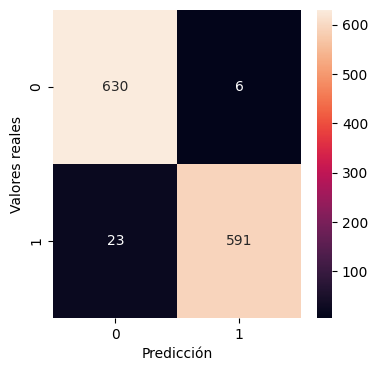

In [134]:
y_pred = random_forest.predict(X_test)
confusion_matrix = confusion_matrix(y_test, y_pred)

plt.subplots(figsize = (4,4))
sns.heatmap(confusion_matrix, annot = True, fmt = '.0f')
plt.xlabel('Predicción')
plt.ylabel('Valores reales')
plt.show

### Resultados

En una muestra de 1250 individuos, la matriz de confusión muestra que el modelo predijo correctamente :

  - **630** verdaderos negativos (esquina superio izquierda).
  - **6** falsos negativos (esquina suprerio derecha).
  - **591** verdaderos positivos (esquina inferior derecha).
  - **23** falsos positivos (esquina inferior izquierda).

### Code | Bosque aleatorio Clasificación (Random forest)

In [135]:
### Code | Bosque aleatorio Clasificación (Random forest)

## 4.6. Detección de valores atípicos (Local Outlier Factor)

### Code | Detección de valores atípicos (Local Outlier Factor)

In [136]:
### Code | Detección de valores atípicos (Local Outlier Factor)

## 4.7. Bosque de aislamiento (Isolation forest)

### Code | Bosque de aislamiento (Isolation forest)

In [137]:
### Code | Bosque de aislamiento (Isolation forest)

## 4.8. Aumento de gradiente (Gradient Boosting)

### Code | Aumento de gradiente (Gradient Boosting)

In [138]:
### Code | Aumento de gradiente (Gradient Boosting)

## 4.9. Bayesiano ingenuo multinomial (MultinomialNB)

### Code | Bayesiano ingenuo multinomial (MultinomialNB)

In [139]:
### Code | Bayesiano ingenuo multinomial (MultinomialNB)